# 00 — Rebuild Dataset & Lane Mask Cache

**Purpose:** recover a usable local dataset root for this notebook runtime, parse BDD100K poly2d lane annotations, render binary lane masks, and verify the dataset pipeline before training.

**Outputs (saved back to Drive):**
- `/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/datasets/bdd100k_vehicle5/masks/train/*.png`
- `/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/datasets/bdd100k_vehicle5/masks/val/*.png`
- `/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/datasets/bdd100k_vehicle5.tar`

**Important:** this notebook must not assume any previously processed local SSD dataset exists. It should always rebuild or recover what it needs, then save results back to Drive for downstream notebooks.


In [2]:
# ── Mount Drive & install deps ──
from google.colab import drive
drive.mount('/content/drive')

!pip install -q yacs tqdm opencv-python-headless

Mounted at /content/drive


In [3]:
# ── Open the repo from Drive ──
import os, sys

REPO_ROOT = '/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane'
os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)
print(f'Working dir: {os.getcwd()}')


Working dir: /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane


In [4]:
# ── Configuration (DETR-style path resolution) ──
import os
from pathlib import Path
from lib.utils.drive_dataset import (
    ensure_local_dataset_from_drive,
    find_raw_bdd_root,
    find_lane_polygon_jsons,
)

PROJECT_ROOT = '/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane'
DATASET_NAME = 'bdd100k_vehicle5'

# Resolve packaged dataset exactly like the working DETR line:
# every notebook must recover its own usable dataset root.
try:
    DATASET_ROOT = ensure_local_dataset_from_drive(DATASET_NAME, PROJECT_ROOT, require_lane_dir=False)
except FileNotFoundError:
    DATASET_ROOT = f'/content/{DATASET_NAME}'
    os.makedirs(DATASET_ROOT, exist_ok=True)
    print(f'Packaged dataset not found yet, temporary local root: {DATASET_ROOT}')

# Raw BDD assets may still live in the shared EcoCAR area used by the DETR line.
RAW_BDD_ROOT = find_raw_bdd_root(PROJECT_ROOT)
BDD_IMAGES = os.path.join(RAW_BDD_ROOT, 'images', '100k')
BDD_LABELS = os.path.join(RAW_BDD_ROOT, 'labels', '100k')

lane_jsons = find_lane_polygon_jsons(RAW_BDD_ROOT)
BDD_LANE_JSON_TRAIN = lane_jsons['train']
BDD_LANE_JSON_VAL = lane_jsons['val']

# Render masks into the packaged dataset root so later notebooks can reuse them.
LANE_MASK_OUT = os.path.join(DATASET_ROOT, 'masks')

# Keep original BDD geometry by default.
MASK_W, MASK_H = 1280, 720
LINE_THICKNESS = 8

print(f'PROJECT_ROOT:        {PROJECT_ROOT}')
print(f'DATASET_ROOT:        {DATASET_ROOT}')
print(f'RAW_BDD_ROOT:        {RAW_BDD_ROOT}')
print(f'BDD_IMAGES:          {BDD_IMAGES}')
print(f'BDD_LABELS:          {BDD_LABELS}')
print(f'BDD_LANE_JSON_TRAIN: {BDD_LANE_JSON_TRAIN}')
print(f'BDD_LANE_JSON_VAL:   {BDD_LANE_JSON_VAL}')
print(f'LANE_MASK_OUT:       {LANE_MASK_OUT}')


Packaged dataset not found yet, temporary local root: /content/bdd100k_vehicle5
PROJECT_ROOT:        /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane
DATASET_ROOT:        /content/bdd100k_vehicle5
RAW_BDD_ROOT:        /content/bdd100k_raw
BDD_IMAGES:          /content/bdd100k_raw/images/100k
BDD_LABELS:          /content/bdd100k_raw/labels/100k
BDD_LANE_JSON_TRAIN: /content/bdd100k_raw/100k/train
BDD_LANE_JSON_VAL:   /content/bdd100k_raw/100k/val
LANE_MASK_OUT:       /content/bdd100k_vehicle5/masks


In [6]:
# ── Debug lane source before rendering ──
from pathlib import Path
from lib.utils.lane_targets import inspect_json_for_lanes

for split, src in [('train', BDD_LANE_JSON_TRAIN), ('val', BDD_LANE_JSON_VAL)]:
    print(f'
=== Debug lane source: {split} ===')
    print('path:', src)
    print('exists:', os.path.exists(src))
    print('is_file:', os.path.isfile(src))
    print('is_dir:', os.path.isdir(src))
    if os.path.isdir(src):
        samples = sorted(str(p) for p in Path(src).glob('*.json'))[:3]
        print('sample json files:', samples)
    print('inspection:')
    for item in inspect_json_for_lanes(src, limit=2):
        print(item)


=== Debug lane source: train ===
path: /content/bdd100k_raw/100k/train
exists: True
is_file: False
is_dir: True
sample json files: ['/content/bdd100k_raw/100k/train/0000f77c-6257be58.json', '/content/bdd100k_raw/100k/train/0000f77c-62c2a288.json', '/content/bdd100k_raw/100k/train/0000f77c-cb820c98.json']
inspection:
{'path': '/content/bdd100k_raw/100k/train/0000f77c-6257be58.json', 'top_type': 'dict', 'record_keys': ['name', 'frames', 'attributes'], 'num_lane_like': 3, 'first_category': 'lane/road curb', 'first_attr_keys': ['direction', 'style'], 'num_polys': 1, 'first_vertices_head': [[503.674413, 373.137193], [357.797732, 374.672737]], 'first_types': 'LL', 'closed': False, 'dense_points_head': [[503.674413, 373.137193], [357.797732, 374.672737]], 'dense_len': 2}
{'path': '/content/bdd100k_raw/100k/train/0000f77c-62c2a288.json', 'top_type': 'dict', 'record_keys': ['name', 'frames', 'attributes'], 'num_lane_like': 8, 'first_category': 'lane/road curb', 'first_attr_keys': ['direction', 

In [8]:
# ── Parse lane labels and render masks ──
from pathlib import Path
from lib.utils.lane_render import convert_bdd_lanes_to_masks, print_lane_stats

for split, json_path in [('train', BDD_LANE_JSON_TRAIN), ('val', BDD_LANE_JSON_VAL)]:
    out_dir = Path(LANE_MASK_OUT) / split
    out_dir.mkdir(parents=True, exist_ok=True)

    existing = len(list(out_dir.glob('*.png')))
    print(f'
=== {split} split ===')
    print(f'  Source: {json_path}')
    print(f'  Output: {out_dir}')
    print(f'  Existing masks: {existing}')

    stats = convert_bdd_lanes_to_masks(
        json_path=json_path,
        output_mask_dir=str(out_dir),
        mask_width=MASK_W,
        mask_height=MASK_H,
        img_width=1280,
        img_height=720,
        line_thickness=LINE_THICKNESS,
        overwrite=False,
    )
    print_lane_stats(stats)
    print(f'  Final mask count: {len(list(out_dir.glob("*.png")))}')


=== train split ===
  Source: /content/bdd100k_raw/100k/train
  Output: /content/bdd100k_vehicle5/masks/train
  Existing masks: 0


Rendering lane masks from directory: 70000it [05:15, 222.19it/s]


Lane render debug examples:
  {'image_name': '0000f77c-6257be58.jpg', 'source': '/content/bdd100k_raw/100k/train/0000f77c-6257be58.json', 'n_lane_labels': 3, 'mask_path': '/content/bdd100k_vehicle5/masks/train/0000f77c-6257be58.png', 'mask_has_pixels': 1}
  {'image_name': '0000f77c-62c2a288.jpg', 'source': '/content/bdd100k_raw/100k/train/0000f77c-62c2a288.json', 'n_lane_labels': 8, 'mask_path': '/content/bdd100k_vehicle5/masks/train/0000f77c-62c2a288.png', 'mask_has_pixels': 1}
  {'image_name': '0000f77c-cb820c98.jpg', 'source': '/content/bdd100k_raw/100k/train/0000f77c-cb820c98.json', 'n_lane_labels': 4, 'mask_path': '/content/bdd100k_vehicle5/masks/train/0000f77c-cb820c98.png', 'mask_has_pixels': 1}

 Lane Mask Statistics
 Total records seen:     70,000
 Total images:          70,000
 Images with lanes:     65,884
 Lane coverage:         94.1%
 Total lane annotations:420,664
 Avg lanes per image:   6.4
 Written masks:         70,000
 Skipped existing:      0
 JSON errors:           

Rendering lane masks from directory: 10000it [00:45, 219.23it/s]

Lane render debug examples:
  {'image_name': 'b1c66a42-6f7d68ca.jpg', 'source': '/content/bdd100k_raw/100k/val/b1c66a42-6f7d68ca.json', 'n_lane_labels': 13, 'mask_path': '/content/bdd100k_vehicle5/masks/val/b1c66a42-6f7d68ca.png', 'mask_has_pixels': 1}
  {'image_name': 'b1c81faa-3df17267.jpg', 'source': '/content/bdd100k_raw/100k/val/b1c81faa-3df17267.json', 'n_lane_labels': 11, 'mask_path': '/content/bdd100k_vehicle5/masks/val/b1c81faa-3df17267.png', 'mask_has_pixels': 1}
  {'image_name': 'b1c81faa-c80764c5.jpg', 'source': '/content/bdd100k_raw/100k/val/b1c81faa-c80764c5.json', 'n_lane_labels': 7, 'mask_path': '/content/bdd100k_vehicle5/masks/val/b1c81faa-c80764c5.png', 'mask_has_pixels': 1}

 Lane Mask Statistics
 Total records seen:     10,000
 Total images:          10,000
 Images with lanes:     9,434
 Lane coverage:         94.3%
 Total lane annotations:60,388
 Avg lanes per image:   6.4
 Written masks:         10,000
 Skipped existing:      0
 JSON errors:           0
  Final ma

train: 70000 lane masks
val: 10000 lane masks


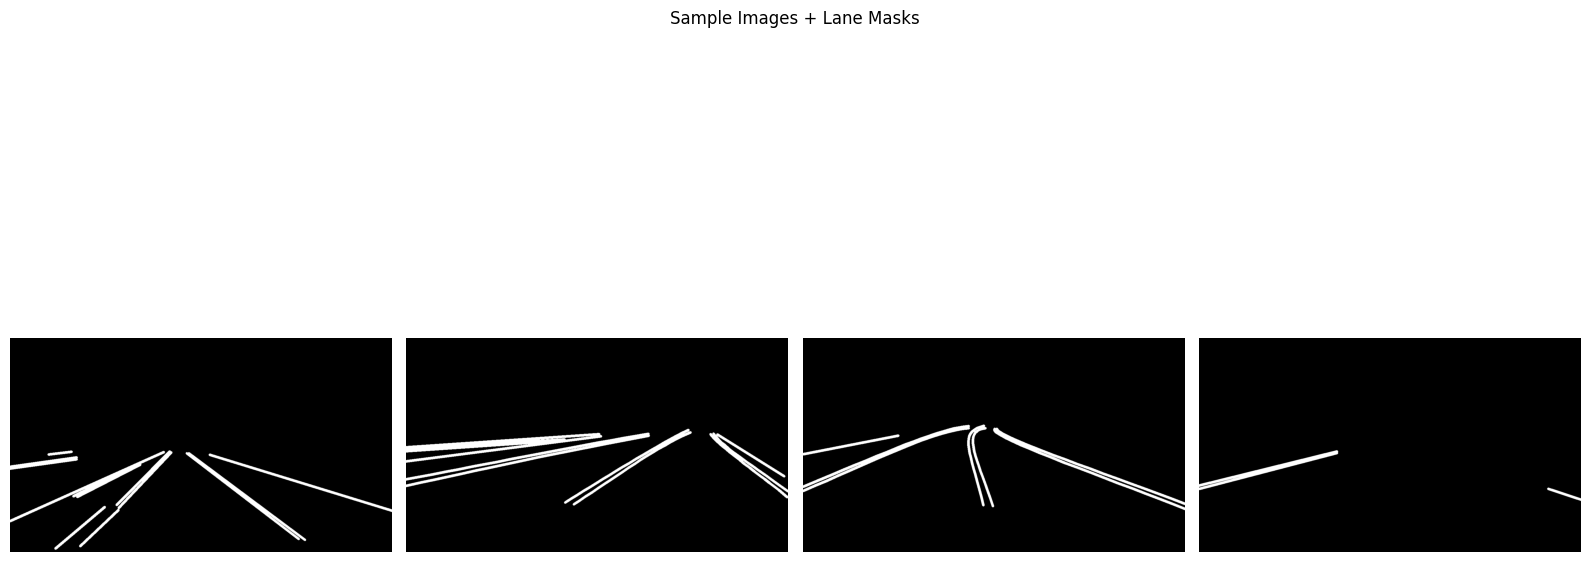

In [9]:
# ── Verify: count masks and spot-check ──
import cv2
import matplotlib.pyplot as plt
import numpy as np

for split in ['train', 'val']:
    mask_dir = Path(LANE_MASK_OUT) / split
    masks = sorted(mask_dir.glob('*.png'))
    print(f'{split}: {len(masks)} lane masks')

val_masks = sorted((Path(LANE_MASK_OUT) / 'val').glob('*.png'))[:4]
if len(val_masks) == 0:
    raise RuntimeError('No validation lane masks were generated. Check the debug cells above before continuing.')

fig, axes = plt.subplots(2, len(val_masks), figsize=(4 * len(val_masks), 6))
if len(val_masks) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for i, mask_path in enumerate(val_masks):
    mask = cv2.imread(str(mask_path), 0)
    img_path = Path(BDD_IMAGES) / 'val' / (mask_path.stem + '.jpg')
    img = cv2.imread(str(img_path))
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(img)
        axes[0, i].set_title(mask_path.stem[:20])
    else:
        axes[0, i].text(0.5, 0.5, 'image missing', ha='center', va='center')
    axes[1, i].imshow(mask, cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].axis('off')
plt.suptitle('Sample Images + Lane Masks')
plt.tight_layout()
plt.show()


In [10]:
# ── Smoke-test dataset pipeline ──
from lib.config import cfg
from lib.dataset import BddDataset
from torch.utils.data import DataLoader
import torchvision.transforms as T

cfg.defrost()
cfg.DATASET.ROOT = DATASET_ROOT
cfg.DATASET.DATAROOT = BDD_IMAGES
cfg.DATASET.LABELROOT = BDD_LABELS
cfg.DATASET.LANEROOT = LANE_MASK_OUT
cfg.freeze()

val_dataset = BddDataset(cfg, is_train=False, inputsize=640, transform=T.ToTensor())
print(f'Val dataset: {len(val_dataset)} samples')
if len(val_dataset) == 0:
    raise RuntimeError('Dataset smoke test found zero samples. Inspect image/label/lane root resolution before continuing.')

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    collate_fn=val_dataset.collate_fn,
)

img, target, paths, shapes = next(iter(val_loader))
det_labels, lane_labels = target
print(f'Image batch shape:  {img.shape}')
print(f'Det labels shape:   {det_labels.shape}')
print(f'Lane labels shape:  {lane_labels.shape}')
print('Dataset pipeline OK!')


[Dataset] split=val | layout=fallback
[Dataset] images=/content/bdd100k_raw/images/100k/val
[Dataset] labels=/content/bdd100k_raw/labels/100k/val
[Dataset] lanes =/content/bdd100k_vehicle5/masks/val
building database...
ERROR: image directory not found: /content/bdd100k_raw/images/100k/val
Val dataset: 0 samples


StopIteration: 

In [ ]:
# ── Persist rebuilt dataset back to Drive for later notebooks ──
import shutil
import tarfile
from pathlib import Path

DRIVE_DATASET_DIR = Path(PROJECT_ROOT) / 'datasets' / DATASET_NAME
DRIVE_TAR_PATH = Path(PROJECT_ROOT) / 'datasets' / f'{DATASET_NAME}.tar'
DRIVE_DATASET_DIR.parent.mkdir(parents=True, exist_ok=True)

local_root = Path(DATASET_ROOT).resolve()
drive_root = DRIVE_DATASET_DIR.resolve()

if local_root != drive_root:
    if DRIVE_DATASET_DIR.exists():
        shutil.rmtree(DRIVE_DATASET_DIR)
    print(f'Copying rebuilt dataset to Drive: {DRIVE_DATASET_DIR}')
    shutil.copytree(DATASET_ROOT, DRIVE_DATASET_DIR, dirs_exist_ok=True)
else:
    print('Dataset root is already on Drive; skipping directory copy.')

if DRIVE_TAR_PATH.exists():
    DRIVE_TAR_PATH.unlink()
print(f'Packing Drive dataset as tar: {DRIVE_TAR_PATH}')
with tarfile.open(DRIVE_TAR_PATH, 'w') as tar:
    tar.add(str(DRIVE_DATASET_DIR), arcname=DATASET_NAME)

print('Saved for downstream notebooks:')
print(f'  Drive dir: {DRIVE_DATASET_DIR}')
print(f'  Drive tar: {DRIVE_TAR_PATH}')
